## NaiveGMM - Tests on synthetic and real data sets

This notebook provides an easy way to test and experiment with NaiveGMM. 

Author: A. Picquenot, 2026

In [1]:
# Import and define everything you need!


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import pandas as pd
from scipy.stats import truncnorm
import random
import time


from NaiveGMM import NaiveGMM

def truncated_gaussian(N, mu, sigma,seed=None, low=0, high=1): # To generate Gaussians between 0 and 1 without worrying about borders
    a, b = (low - mu) / sigma, (high - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=N,random_state=seed) # Seed to have same distribution at every run

def generate_two_gaussians(N1, N2, mu1=0.3, sigma1=0.1, mu2=0.7, sigma2=0.1,seed=None):
    g1 = truncated_gaussian(N1, mu1, sigma1,seed)
    g2 = truncated_gaussian(N2, mu2, sigma2,seed)
    return g1, g2

## Test on simulations - Synthetic Gaussians

The following cell randomly generates two synthetic Gaussians of the chosen dimension and applies K-means, AutoGMM, and NaiveGMM to separate them. Parameters used in the tests from the paper are written in comment.

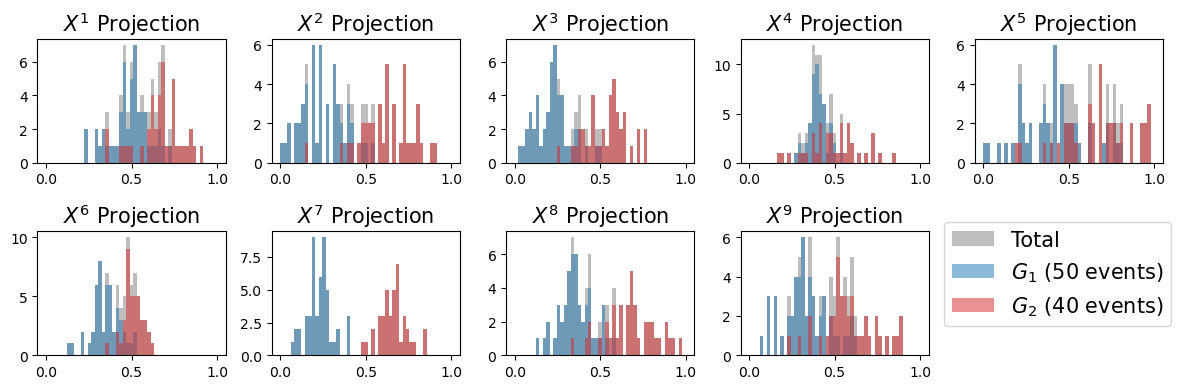

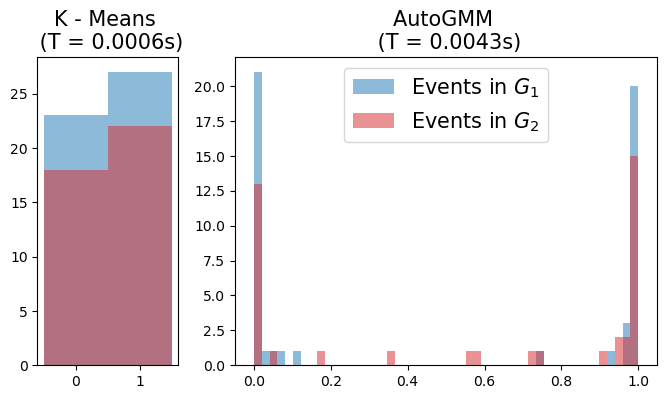

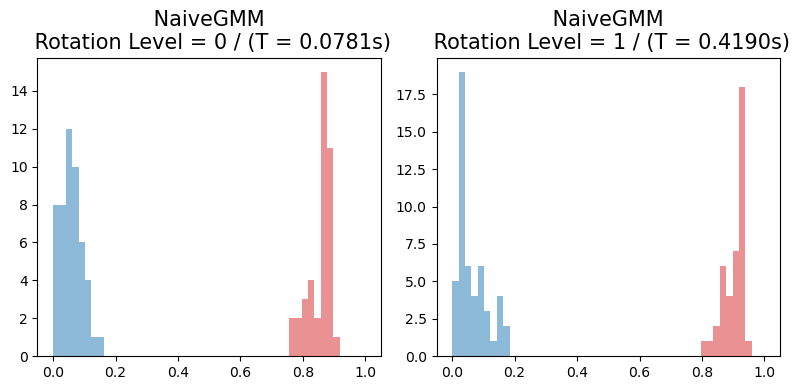

In [9]:
################# Parameters to play with ####################


NDIM=9 # Dimensionality of the dataset to generate and separate
N_1=50 # Number of events in G1
N_2=40 # Number of events in G2
L_max=1 # Rotation Level max for NaiveGMM, must be < NDIM
correlation_2D=False # Induce correlation between dim 1 and dim 2
random_seed=11  # Comment for randomness, select a seed for reproducibility

# If N_1 and N_2 are close enough, it might be necessary to reorder the labels in the plots, see below

################ 2D Example from the paper: ##################
#
#    NDIM=2
#    N_1=1000
#    N_2=500
#    L_max=1
#    correlation_2D = True
#
#    random_seed=103 
#
################ 3D Example from the paper: ##################
#
#    NDIM=3
#    N_1=700
#    N_2=300
#    L_max=2
#    correlation_2D = False
#
#    random_seed=0 
#
################ 9D Example from the paper: ##################
#
#    NDIM=9
#    N_1=50
#    N_2=40
#    L_max=1
#    correlation_2D = False
#
#    random_seed=11 
#
##############################################################

random.seed(random_seed) 

BINS=np.linspace(0,1,50)
DATA=[]
G1=[]
G2=[]

for i in range(NDIM):

# Gaussian parameters generated randomly. Bounds chosen to have both truncated gaussians "look like gaussians" on [0,1]
    sigma1=random.uniform(0.05, .2)
    sigma2=random.uniform(0.05, .2)
    mu1=random.uniform(0.2, .5) 
    mu2=random.uniform(0.5, .8)
    
    g1, g2 = generate_two_gaussians(N_1, N_2,mu1,sigma1,mu2,sigma2,seed=i)

    if (correlation_2D==True) & (i==1): 
        g1=g1*G1[0]
        g2=g2*G2[0]
    
    data = np.concatenate((g1,g2))
    
    DATA.append(data)
    G1.append(g1)
    G2.append(g2)
    
    
DATA=np.asarray(DATA)



if NDIM==2:
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 3])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])
    
    ax1.hist(DATA[0], bins=BINS, alpha=0.5, color='tab:grey', label="Total")
    ax1.hist(G1[0], bins=BINS, alpha=0.5, color='tab:blue', label="$G_1$")
    ax1.hist(G2[0], bins=BINS, alpha=0.5, color='tab:red', label="$G_2$")
    ax1.set_title("$X^1$ Projection",fontsize=15)

    ax2.hist(DATA[1], bins=BINS, alpha=0.5, color='tab:grey', label="Total")
    ax2.hist(G1[1], bins=BINS, alpha=0.5, color='tab:blue', label="$G_1$")
    ax2.hist(G2[1], bins=BINS, alpha=0.5, color='tab:red', label="$G_2$")
    ax2.set_title("$X^2$ Projection",fontsize=15)
    
    ax3.scatter(DATA[0,:N_1],DATA[1,:N_1], color='tab:blue', label="$G_1$ (%i events)"%N_1)
    ax3.scatter(DATA[0,N_1:],DATA[1,N_1:], color='tab:red', label="$G_2$ (%i events)"%N_2)
    ax3.set_title("2D Representation",fontsize=15)

    ax3.set_xlim(0,1)
    ax3.set_ylim(0,1)
    ax1.legend(fontsize=15)
    ax2.legend(fontsize=15)
    ax3.legend(fontsize=15)
    plt.tight_layout()
    plt.show()
    


if NDIM==3:


    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 2])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, :], projection='3d')
    
    ax1.hist(DATA[0], bins=BINS, alpha=0.5, color='tab:grey', label="Total")
    ax1.hist(G1[0], bins=BINS, alpha=0.5, color='tab:blue', label="$G_1$")
    ax1.hist(G2[0], bins=BINS, alpha=0.5, color='tab:red', label="$G_2$")
    ax1.set_title("$X^1$ Projection",fontsize=15)

    ax2.hist(DATA[1], bins=BINS, alpha=0.5, color='tab:grey', label="Total")
    ax2.hist(G1[1], bins=BINS, alpha=0.5, color='tab:blue', label="$G_1$")
    ax2.hist(G2[1], bins=BINS, alpha=0.5, color='tab:red', label="$G_2$")
    ax2.set_title("$X^2$ Projection",fontsize=15)

    ax3.hist(DATA[2], bins=BINS, alpha=0.5, color='tab:grey', label="Total")
    ax3.hist(G1[2], bins=BINS, alpha=0.5, color='tab:blue', label="$G_1$")
    ax3.hist(G2[2], bins=BINS, alpha=0.5, color='tab:red', label="$G_2$")
    ax3.set_title("$X^3$ Projection",fontsize=15)
    
    ax4.scatter(DATA[0,:N_1],DATA[1,:N_1], color='tab:blue', label="$G_1$ (%i events)"%N_1)
    ax4.scatter(DATA[0,N_1:],DATA[1,N_1:], color='tab:red', label="$G_2$ (%i events)"%N_2)
    ax4.set_title("3D Representation",fontsize=15)

    ax1.legend(fontsize=15)
    ax4.legend(fontsize=15)
    plt.tight_layout()
    plt.show()

if NDIM>3:
    if NDIM%5==0: n_row = NDIM // 5
    else: n_row = NDIM // 5 + 1

    fig, axes = plt.subplots(n_row,5,figsize=(12, n_row*2))

    if n_row==1:
        for i in range(NDIM):

            if i==0:
                label_tot="Total"
                label1="$G_1$ (%i events)"%N_1
                label2="$G_2$ (%i events)"%N_2
            else:
                label_tot=None
                label1=None
                label2=None
    
            axes[i%5].hist(DATA[i], bins=BINS, alpha=0.5, color='tab:grey', label=label_tot)
            axes[i%5].hist(G1[i], bins=BINS, alpha=0.5, color='tab:blue', label=label1)
            axes[i%5].hist(G2[i], bins=BINS, alpha=0.5, color='tab:red', label=label2)
            axes[i%5].set_title("$X^{%i}$ Projection"%(i+1),fontsize=15)
        if NDIM%5!=0:
            for i in range(5-NDIM%5):
                axes[4-i].remove()
            fig.legend(loc="center right",bbox_to_anchor=(0.98, 0.2),fontsize=15)


    else:
        for i in range(NDIM):
            if i==0:
                label_tot="Total"
                label1="$G_1$ (%i events)"%N_1
                label2="$G_2$ (%i events)"%N_2
            else:
                label_tot=None
                label1=None
                label2=None
                
    
            axes[i//5,i%5].hist(DATA[i], bins=BINS, alpha=0.5, color='tab:grey', label=label_tot)
            axes[i//5,i%5].hist(G1[i], bins=BINS, alpha=0.5, color='tab:blue', label=label1)
            axes[i//5,i%5].hist(G2[i], bins=BINS, alpha=0.5, color='tab:red', label=label2)
            axes[i//5,i%5].set_title("$X^{%i}$ Projection"%(i+1),fontsize=15)
    
        if NDIM%5!=0:
            for i in range(5-NDIM%5):
                axes[n_row-1,4-i].remove()
            fig.legend(loc="center right",bbox_to_anchor=(1, 0.3),fontsize=15)

    if NDIM%5==0: fig.legend(loc="center right",bbox_to_anchor=(1.19, 0.6),fontsize=15)
    plt.tight_layout()
    
    plt.show()
    
##### AutoGMM Results #####

X = DATA.reshape(-1, DATA.shape[0])   # IMPORTANT: shape (N, 1)
start_time = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(X)
probs = gmm.predict_proba(X)
if probs[:, 0].sum()>probs[:, 1].sum():  #May need to change the order
    Auto_PROBA_G2 = probs[:, 0]
else:
    Auto_PROBA_G2 = probs[:, 1]

end_time = time.perf_counter()
Time_Auto = end_time - start_time



##### K-Means Results #####

start_time = time.perf_counter()
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
Kmean_PROBA_G2 = kmeans.labels_
if len(Kmean_PROBA_G2[Kmean_PROBA_G2==0])>len(Kmean_PROBA_G2[Kmean_PROBA_G2==1]):   #May need to change the order
    Kmean_PROBA_G2 = abs(1-Kmean_PROBA_G2)

end_time = time.perf_counter()
Time_Kmeans = end_time - start_time


##### Plot All #####

fig = plt.figure(figsize=(8,4))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.hist(Kmean_PROBA_G2[:N_1], bins=np.arange(3)-0.5, color='tab:blue', alpha=0.5,  label="Events in $G_1$")
ax1.hist(Kmean_PROBA_G2[N_1:], bins=np.arange(3)-0.5, color='tab:red', alpha=0.5,  label="Events in $G_2$")
ax1.set_title("K - Means \n (T = %.4fs)"%Time_Kmeans,fontsize=15)

ax2.hist(Auto_PROBA_G2[:N_1], bins=BINS, color='tab:blue', alpha=0.5,  label="Events in $G_1$")
ax2.hist(Auto_PROBA_G2[N_1:], bins=BINS, color='tab:red', alpha=0.5,  label="Events in $G_2$")
ax2.set_title("AutoGMM \n (T = %.4fs)"%Time_Auto,fontsize=15)

plt.legend(fontsize=15)
plt.show()

##### NaiveGMM Results #####

Naive_PROBA_G2=[]
Time_Naive=[]
for L in range(L_max+1):
    start_time = time.perf_counter()
    
    Naive_PROBA_G2_ = 1 - NaiveGMM(DATA,Rotation_Level=L,Angles=[np.pi/4],normalize_rot=False,show_warnings=False,max_run=1000) 
    # Remove the "1-" to reorder if necessary
    # normalize_rot=True and large max_run are useful to maximize number of good fits, in general not useful
    Naive_PROBA_G2.append(Naive_PROBA_G2_)
    end_time = time.perf_counter()
    Time_Naive.append(end_time - start_time)

fig, axes = plt.subplots(1,L_max+1,figsize=((L_max+1)*4,4))

if L==0:
    axes.hist(Naive_PROBA_G2[L][:N_1], bins=BINS, color='tab:blue', alpha=0.5)
    axes.hist(Naive_PROBA_G2[L][N_1:], bins=BINS, color='tab:red', alpha=0.5)
    axes.set_title(" NaiveGMM \n Rotation Level = %i / (T = %.4fs)"%(L,Time_Naive[L]),fontsize=15)

if L>0:
    for L in range(L_max+1): 
            
        axes[L].hist(Naive_PROBA_G2[L][:N_1], bins=BINS, color='tab:blue', alpha=0.5)
        axes[L].hist(Naive_PROBA_G2[L][N_1:], bins=BINS, color='tab:red', alpha=0.5)
    
        axes[L].set_title(" NaiveGMM \n Rotation Level = %i / (T = %.4fs)"%(L,Time_Naive[L]),fontsize=15)
plt.tight_layout()
plt.show()

## Application on real data - Breast Cancer Dataset 

The following cell loads the Wisconsin Breast Cancer dataset from sklearn.datasets, normalizes the 30 features, and applies K-Means, AutoGMM, and NaiveGMM. The labels show the actual diagnostics.

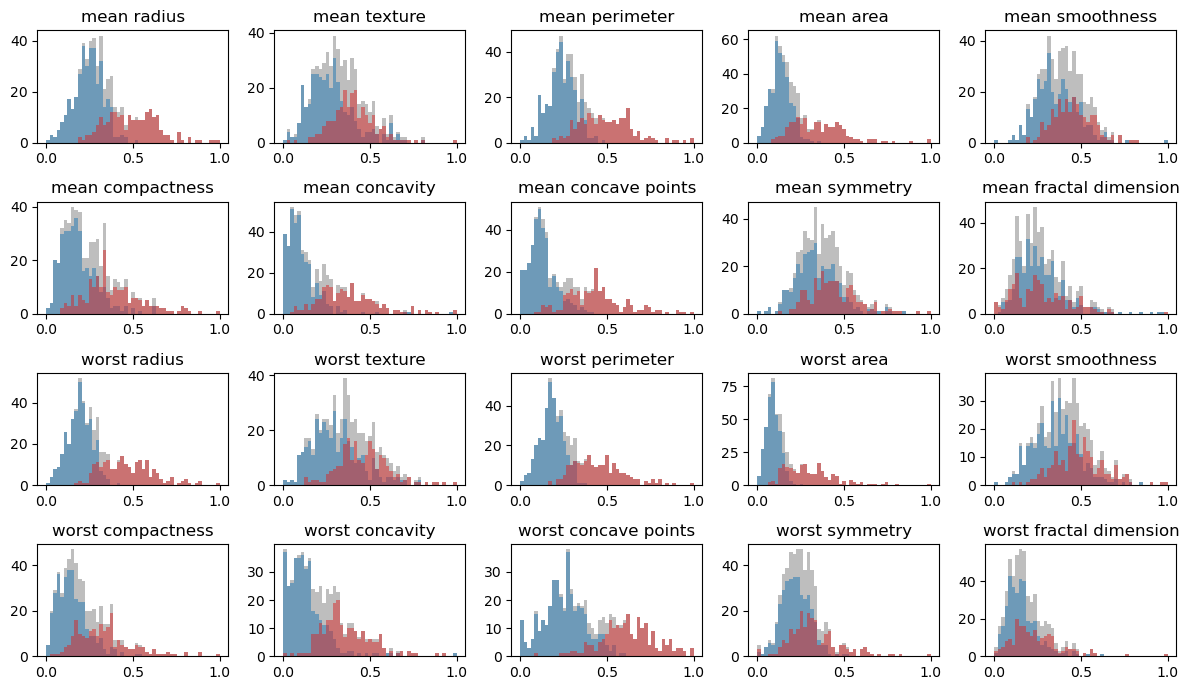

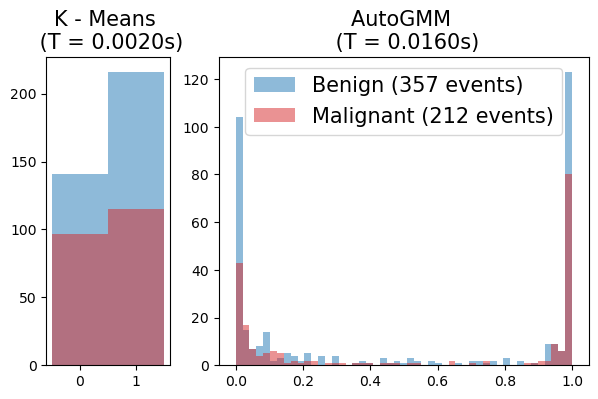

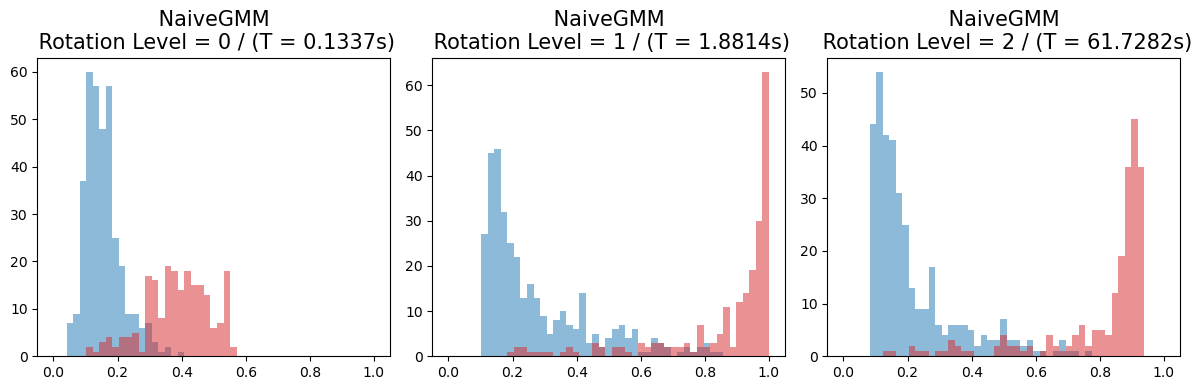

In [8]:

L_max=2 # Rotation Level max for NaiveGMM, must be < NDIM

#########################################################


cancer = load_breast_cancer()


feat_list=['mean radius','mean texture','mean perimeter','mean area','mean smoothness','mean compactness', 'mean concavity',
       'mean concave points','mean symmetry','mean fractal dimension','worst radius','worst texture','worst perimeter',
           'worst area','worst smoothness','worst compactness', 'worst concavity',
       'worst concave points','worst symmetry','worst fractal dimension']

cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
Labels=cancer['target']
N_1=len(Labels[Labels==1])
N_2=len(Labels[Labels==0])

cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)[feat_list]

cancer_df=(cancer_df-cancer_df.min())/(cancer_df.max()-cancer_df.min()) # Normalization

DATA = np.asarray(cancer_df).T
BINS=np.linspace(0,1,50)

fig, axes = plt.subplots(4,5,figsize=(12, 7))

for i,name in enumerate(cancer_df.columns):
    
    axes[i//5,i%5].hist(DATA[i], bins=BINS, alpha=0.5, color='tab:grey',  label="Total")
    axes[i//5,i%5].hist(cancer_df[name][Labels==1],bins=BINS, color='tab:blue', alpha=0.5,  label="Benign")
    axes[i//5,i%5].hist(cancer_df[name][Labels==0],bins=BINS, color='tab:red', alpha=0.5,  label="Malignant")
    axes[i//5,i%5].set_title(name)
plt.tight_layout()
plt.show()


##### AutoGMM Results #####

X = DATA.reshape(-1, DATA.shape[0])   # IMPORTANT: shape (N, 1)
start_time = time.perf_counter()
gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(X)
probs = gmm.predict_proba(X)
if probs[:, 0].sum()>probs[:, 1].sum():  #May need to change the order
    Auto_PROBA_G2 = probs[:, 0]
else:
    Auto_PROBA_G2 = probs[:, 1]

end_time = time.perf_counter()
Time_Auto = end_time - start_time

##### K-Means Results #####

start_time = time.perf_counter()
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
Kmean_PROBA_G2 = kmeans.labels_
if len(Kmean_PROBA_G2[Kmean_PROBA_G2==0])>len(Kmean_PROBA_G2[Kmean_PROBA_G2==1]):   #May need to change the order
    Kmean_PROBA_G2 = abs(1-Kmean_PROBA_G2)
end_time = time.perf_counter()
Time_Kmeans = end_time - start_time

##### Plot Both #####

fig = plt.figure(figsize=(7,4))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax1.hist(Kmean_PROBA_G2[Labels==1], bins=np.arange(3)-0.5, color='tab:blue', alpha=0.5,  label="Benign (%i events)"%N_1)
ax1.hist(Kmean_PROBA_G2[Labels==0], bins=np.arange(3)-0.5, color='tab:red', alpha=0.5,  label="Malignant (%i events)"%N_2)
ax1.set_title("K - Means \n (T = %.4fs)"%Time_Kmeans,fontsize=15)
ax2.hist(Auto_PROBA_G2[Labels==1], bins=BINS, color='tab:blue', alpha=0.5,  label="Benign (%i events)"%N_1)
ax2.hist(Auto_PROBA_G2[Labels==0], bins=BINS, color='tab:red', alpha=0.5,  label="Malignant (%i events)"%N_2)
ax2.set_title("AutoGMM \n (T = %.4fs)"%Time_Auto,fontsize=15)
plt.legend(fontsize=15)
plt.show()

##### NaiveGMM Results #####

Naive_PROBA_G2=[]
Time_Naive=[]

for L in range(L_max+1):
    start_time = time.perf_counter()
    Naive_PROBA_G2_ = 1 - NaiveGMM(DATA,Rotation_Level=L,Angles=[np.pi/4],normalize_rot=False,show_warnings=False,max_run=1000)  
    # Remove the "1-" to reorder if necessary
    # normalize_rot=True and large max_run are useful to maximize number of good fits, in general not useful
    Naive_PROBA_G2.append(Naive_PROBA_G2_)
    end_time = time.perf_counter()
    Time_Naive.append(end_time - start_time)

fig, axes = plt.subplots(1,L_max+1,figsize=((L_max+1)*4,4))

if L==0:
    axes.hist(Naive_PROBA_G2[L][Labels==1], bins=BINS, color='tab:blue', alpha=0.5)
    axes.hist(Naive_PROBA_G2[L][Labels==0], bins=BINS, color='tab:red', alpha=0.5)
    axes.set_title(" NaiveGMM \n Rotation Level = %i / (T = %.4fs)"%(L,Time_Naive[L]),fontsize=15)

if L>0:
    for L in range(L_max+1): 
            
        axes[L].hist(Naive_PROBA_G2[L][Labels==1], bins=BINS, color='tab:blue', alpha=0.5)
        axes[L].hist(Naive_PROBA_G2[L][Labels==0], bins=BINS, color='tab:red', alpha=0.5)
    
        axes[L].set_title(" NaiveGMM \n Rotation Level = %i / (T = %.4fs)"%(L,Time_Naive[L]),fontsize=15)

plt.tight_layout()
plt.show()